# Moving Average Crossover Backtest: AAPL

This is a small project where I test a simple trading strategy against AAPL stock data from 2019 to 2026, and compare it to just buying and holding the stock.

The strategy is based on moving average crossovers, when a short-term average price crosses above a long-term average price, that is treated as a buy signal and when it crosses below, that's a sell signal. It is one of the most common beginner strategies in trading.

**What I did:**

- Pulled AAPL price data
- Calculated a 20-day and 50-day moving average
- Built buy/sell signals based on when they cross
- Compared the strategy's returns against just holding the stock
- Checked max drawdown to see which one was riskier

**Tools:** `yfinance`, `Pandas`, `NumPy`, `Matplotlib`

## Getting the data

I pulled daily AAPL price data from 2019 to early 2026 using yfinance. This range covers a bunch of different market conditions, specifically the COVID-19 crash, 2022 downturn and even a long recovery, so it's a normal stretch to actually test a strategy on.

In [4]:
import yfinance as yf

data = yf.download("AAPL", start="2019-01-01", end="2026-01-01")
data.head()

/tmp/ipykernel_644/543573632.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2019-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.436916,37.657386,36.562155,36.718617,148158800
2019-01-03,33.707916,34.544747,33.662874,34.132257,365248800
2019-01-04,35.146896,35.215647,34.089599,34.262654,234428400
2019-01-07,35.068661,35.282019,34.587424,35.251200,219111200
2019-01-08,35.737186,35.990845,35.208538,35.455081,164101200


## Moving averages

I calculated a 20day and a 50day moving average from the closing price. These two lines are what the whole strategy is built on.

In [6]:
data['SMA_short'] = data['Close'].rolling(window=20).mean()
data['SMA_long'] = data['Close'].rolling(window=50).mean()
data.tail()

Price,Close,High,Low,Open,Volume,SMA_short,SMA_long
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2025-12-24,273.066742,274.682340,271.461127,271.600731,17910600,276.399652,270.219039
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800,276.192714,270.703749
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,275.938907,271.233300
2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600,275.439267,271.652845
2025-12-31,271.122009,272.937076,271.012322,272.318764,27293600,274.724712,271.849788


## Building the signal

This is the actual strategy logic. If the 20day average is above the 50day average, the signal is 1, meaning I'd be holding the stock. If it's below, the signal is 0, meaning I'd be sitting out.

In [7]:
data['Signal'] = 0

data.loc[data['SMA_short'] > data['SMA_long'], 'Signal'] = 1
data[[ 'Close', 'SMA_short', 'SMA_long', 'Signal']].tail(10)

Price,Close,SMA_short,SMA_long,Signal
Ticker,AAPL,,,
Date,,,,
2025-12-17,271.102051,276.209666,267.996821,1
2025-12-18,271.451111,276.390674,268.283639,1
2025-12-19,272.927124,276.760667,268.680081,1
2025-12-22,270.234467,276.734740,269.197424,1
2025-12-23,271.620667,276.557222,269.694867,1
2025-12-24,273.066742,276.399652,270.219039,1
2025-12-26,272.657806,276.192714,270.703749,1
2025-12-29,273.016876,275.938907,271.233300,1


## Calculating returns

Daily returns are calculated from the closing price. The strategy's return depends on previous day's signal, not the day itself's, as a signal can only be acted on the day after it's generated.

In [8]:
data['Daily_Return'] = data['Close'].pct_change()
data['Strategy_Return'] = data['Daily_Return'] * data['Signal'].shift(1)
data[['Close', 'Signal', 'Daily_Return', 'Strategy_Return']].tail(10)

Price,Close,Signal,Daily_Return,Strategy_Return
Ticker,AAPL,,,
Date,,,,
2025-12-17,271.102051,1,-0.010087,-0.010087
2025-12-18,271.451111,1,0.001288,0.001288
2025-12-19,272.927124,1,0.005437,0.005437
2025-12-22,270.234467,1,-0.009866,-0.009866
2025-12-23,271.620667,1,0.005130,0.005130
2025-12-24,273.066742,1,0.005324,0.005324
2025-12-26,272.657806,1,-0.001498,-0.001498
2025-12-29,273.016876,1,0.001317,0.001317


## Adding it all up

This compounds the daily returns over time, so I can see how $1 would have grown if I just held the stock versus if I followed the strategy the whole way through.

In [9]:
data['Cumulative_Market_Return'] = (1 + data['Daily_Return']).cumprod()
data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()
data[['Cumulative_Market_Return', 'Cumulative_Strategy_Return']].tail(10)

Price,Cumulative_Market_Return,Cumulative_Strategy_Return
Ticker,,
Date,,
2025-12-17,7.241570,3.063906
2025-12-18,7.250894,3.067851
2025-12-19,7.290321,3.084532
2025-12-22,7.218395,3.054101
2025-12-23,7.255423,3.069767
2025-12-24,7.294050,3.086110
2025-12-26,7.283127,3.081489
2025-12-29,7.292718,3.085547


## Plotting it out

This graph makes the difference between the two approaches easy to see.

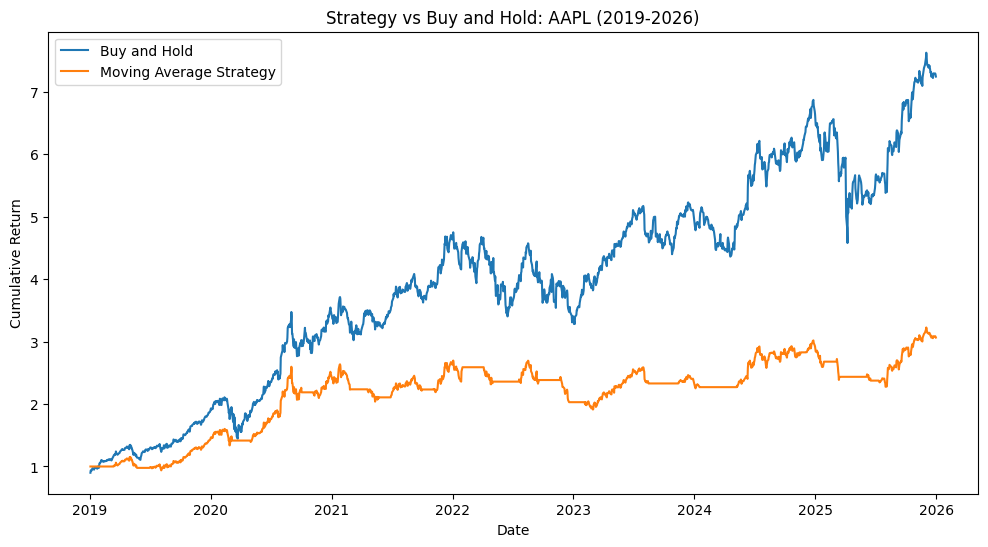

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['Cumulative_Market_Return'], label='Buy and Hold')
plt.plot(data['Cumulative_Strategy_Return'], label='Moving Average Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs Buy and Hold: AAPL (2019-2026)')
plt.legend()
plt.show()

## Checking the risk side

Returns aren't the whole story, a strategy that makes less money but also loses less during a crash can still be worth something. Max drawdown shows the biggest drop each approach took from its peak.

In [11]:
def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

market_dd = max_drawdown(data['Cumulative_Market_Return'])
strategy_dd = max_drawdown(data['Cumulative_Strategy_Return'])

print(f"Buy and Hold Max Drawdown: {market_dd:.2%}")
print(f"Strategy Max Drawdown: {strategy_dd:.2%}")

Buy and Hold Max Drawdown: -33.36%
Strategy Max Drawdown: -29.09%


## What I found

Buy and hold clearly won on returns, $1 turned into about 7.24, versus 3.06 with the strategy.

But the strategy did lose less during downturns, its max drawdown was -29.09% compared to -33.36% for just holding.

Honestly this tracks with what I expected. Simple moving average strategies tend to get "Whipsawed" out of the market and miss the sharp recoveries, which really adds up. If I wanted to genuinely improve this, I would probably look at combining it with another signal, or testing it on an asset where trend following historically works better.



## Where this could go further

This strategy is about as simple as trend following is, and that's kind of the whole point. A few things this could get meaningfully more advanced:

- **Multiple signals combined:** real strategies rarely rely on just one indicator. Adding something like RSI or volume based confirmation could reduce false signals during choppy periods.

- **Position sizing:** right now the strategy is either fully in or fully out. A more advanced version might scale position size based on signal strength or volatility, rather than a hard on/off switch.

- **Transaction costs:** this backtest assumes free trading. Real strategies need to account for fees and slippage, which can eat into returns for strategies that trade frequently

- **Different asset classes:** trend following strategies like this tend to perform better in commodities or currency markets than in a single high growth stock like AAPL, since those markets often have longer and cleaner trends.

- **Machine learning based signals:** instead of a fixed rule like moving average crossover, a model could be trained to learn more complex, non linear patterns in price behavior, which is closer to how real quant research approaches signal generation.

This project was meant to be a clear, understandable first step into backtesting rather than a genuinely competitive strategy, but these are the directions that are worth exploring.